# Introduction to Machine Learning (CSCI-UA.473)

### Programming Assignment 3 (Total: 100 points)
#### Due: November 25, 2025 at 11:59PM


#### Name: (Ruixiang Zhu)
#### Email: (rz2718@nyu.edu)

## Summary and Assignment Requirements
This assigment consists of five parts.

For **Parts 1-3**, you will train a convolutional neural network (CNN) using PyTorch on the [CIFAR-10 dataset](https://en.wikipedia.org/wiki/CIFAR-10). CIFAR-10 is composed of 32×32 color images drawn from 10 categories such as cats, airplanes, and cars. Your main goal is to understand the end-to-end process of building and training a neural network: defining the model structure, preparing the data, writing the training loop, monitoring loss/accuracy, and evaluating performance on unseen data.

For **Part 4**, you will implement a k nearest neighbor (kNN) classifier to make predictions of car sales. We will explore the effect of kNN's hyperparameters and the effect of normalization on its performance.

For **Part 5**, you will use decision trees and random forests on the same dataset as used in the second part, and the questions will reveal key properties behind decision trees and bagging.

**IMPORTANT**: You are only allowed to use packages that are already imported in this assignment, with exceptions given only to visualization packages. You may use whatever package you prefer for visualizations (e.g., matplotlib, seaborn).

**IMPORTANT**: You should not delete any comments with `TODO`'s in the code, and you must fill your code after the corresponding `TODO` for each task.

### Tips:
* If you are not familiar with PyTorch, you are recommended to spend some time understanding the PyTorch documentation while completing this homework. https://docs.pytorch.org/docs/stable/index.html.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data.dataset import random_split
from torchvision import datasets
from sklearn.metrics import confusion_matrix
import PIL

## CNN Part 1: Preparation

In this section, you will load the data and decide on the model architecture.

The provided `Net` class defines the core components of a small CNN: two convolutional layers, batch normalization layers, and three fully connected layers. Your tasks involve adding necessary operations such as pooling and reshaping so that the network’s output can flow correctly from one stage to the next.

### Task 1.1 (3 points)
Recall from class that max pooling reduces the spatial dimensions and helps the network focus on the strongest features while reducing computation.
In the provided `Net` class, implement the max pooling layers at locations with `TODO 1.1`'s in the code below.

### Task 1.2 (3 points)
After the max pooling, note that the next layers in the sequence are fully-connected layers. Fully connected layers require flattened vector inputs. After the final pooling layer, your tensor still has a height and width. we need to reshape the output so that we can feed it to a fully connected layer, complete ``TODO 1.2``.

### Task 1.3 (3 points)
In the `Net` class, we wrote `class Net(nn.Module)`, which inherits `torch`'s `nn.Module` class. Why is this step needed? What would happen if we don't do inheritance and instead wrote `class Net`? Answer in words.

**Answer**:

In the Net class we inherit from nn.Module so that our model becomes a proper PyTorch module.
This makes PyTorch automatically register all sub-layers (conv1, conv2, bn1, fc1, etc.) as parameters of the model.
Because of this we can call methods like net.parameters() (used by the optimizer), net.to(device) (move all parameters to GPU/CPU), net.train() / net.eval(), and state_dict() for saving and loading.
If we just wrote class Net: without inheriting nn.Module, these features would not work: the optimizer would not see any parameters, the model could not be moved to GPU with .to(device), and net(x) would not automatically call a forward method in the same standardized way.

In [ ]:
## Do not touch this cell
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, 5)
        self.conv2 = nn.Conv2d(8, 16, 3)
        self.bn1 = nn.BatchNorm2d(8)
        self.bn2 = nn.BatchNorm2d(16)
        self.fc1 = nn.Linear(16*6*6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        # TODO 1.1: implement max pooling layer
        out = max_pool(out)

        out = F.relu(self.bn2(self.conv2(out)))
        # TODO 1.1: implement max pooling layer (another one!)
        out = max_pool(out)

        # TODO 1.2: reshape the output from the previous layer
        # so that it works for the next fully-connected layer
        out = reshape(out)  # from [N,16,6,6] to [N, 16*6*6]
        out = relu(fc1(out))


        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, 5)
        self.conv2 = nn.Conv2d(8, 16, 3)
        self.bn1   = nn.BatchNorm2d(8)
        self.bn2   = nn.BatchNorm2d(16)

        self.pool  = nn.MaxPool2d(2, 2)          # <<< add this

        self.fc1 = nn.Linear(16*6*6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.pool(out)                     # max pool after conv1

        out = F.relu(self.bn2(self.conv2(out)))
        out = self.pool(out)                     # max pool after conv2

        out = out.view(out.size(0), -1)          # flatten: Task 1.2

        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out


In [ ]:
##Do Not Touch This Cell
device = 'cuda' if torch.cuda.is_available() else 'cpu'
net = Net().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.05, momentum=0.5)
if device =='cuda':
    print("Train on GPU...")
else:
    print("Train on CPU...")

Train on GPU...


Next, you will prepare the data for the model to ingest.

### Task 1.4 (3 points)
CIFAR-10 contains 50,000 training images. You will create an 80/20 split, which is a common setup to evaluate models.

### Task 1.5 (3 points)
PyTorch DataLoaders manage batching and shuffling.

1. Load the datasets (training, validation, and test sets) into a PyTorch DataLoader. Make sure to set `shuffle=True` on the training set.

2. What does shuffling do? Why does it matter for training models? Answer in words.

Shuffling means we randomly change the order of the training examples before forming mini-batches for each epoch.
This matters because it makes every batch look like a random sample from the whole dataset, instead of all similar examples (e.g., all “airplane” images) being grouped together.
Random batches give more stable, less biased gradient updates, help the optimizer converge faster, and reduce the risk that the model just adapts to the particular ordering of the data instead of learning general patterns.

In [ ]:
train_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])
test_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

##TODO 1.3: Split the set into 80% train, 20% validation (there are 50K total images)
train_size = int(0.8 * len(dataset))   # 40000
val_size   = len(dataset) - train_size # 10000
train_set, val_set = random_split(dataset, [train_size, val_size])


##TODO 1.4: Load train_set and val_set into PyTorch DataLoader

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
from torch.utils.data import DataLoader  # add this near the imports if not already

BATCH_SIZE = 256

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

##TODO 1.4: Load test_set into PyTorch DataLoader

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:03<00:00, 48.3MB/s]


**Answer:** *Write the answer to Task 1.5.2 here.*

## CNN Part 2: Model Training

Now, we have set up our model and data. The next step is to write the training loop!

A traditional training loop has the following steps:
1. Set the model to training mode
2. Pass inputs through the model to get predictions (the forward pass)
3. Compute the loss
4. Update the model (backward pass and optimizer step)

You will fill in each of these pieces and reason about what is happening.


### Task 2.1 (1 point)
1. Set the model (neural network) to training mode by completing `TODO 2.1`.

2. Why is this step needed? Consider what would happen if we skip this step. Answer in words.

**Answer**:

We call net.train() to put the network in training mode.
In training mode, special layers such as BatchNorm and Dropout behave differently than in evaluation mode: BatchNorm uses the statistics of the current mini-batch, and Dropout (if present) randomly drops units.
If we skip this step and the model stays in evaluation mode (after a previous net.eval()), BatchNorm will use its stored running statistics and Dropout will be turned off. Then the model’s behaviour during training will not match its intended training behaviour, the gradients will be based on the wrong computations, and learning can become unstable or fail to generalize.

### Task 2.2 (2 points)
1. Complete `TODO 2.2`.
2. What does it do? Why? Explain in words. Your explanation should describe where information flows, what the model is trying to compute when performing this step, and how the output of this step influences the loss. You should also comment on how this relates to the computation graph.

**Answer**:

## 2.2
outputs = net(data) runs a forward pass of the current mini-batch through the network.
The input tensor data flows through all layers (convolutions, nonlinearities, linear layers, etc.), and the network uses its current parameters to compute a vector of scores (logits) for each class for every sample in the batch.

When this forward pass is done with gradient tracking on (the default in train mode), PyTorch builds a computation graph that records all operations used to produce outputs from data and the model parameters. The next line uses these outputs to compute the cross-entropy loss against the true labels, so any change in the outputs (and thus in the underlying weights) will change the loss. Later, when we call loss.backward(), PyTorch traverses this computation graph from the loss back to all parameters and computes gradients, which are then used by optimizer.step() to update the model. So this step is what connects the input data to the loss and makes learning possible.

### Task 2.3 (3 points)
1. Complete `TODO 2.3`.

2. We are using cross entropy loss, does minimizing cross entropy equivalent to maximum likelihood estimation? Why? Explain in words or mathematical notations.

**Answer**:

Does minimizing cross-entropy equal maximum likelihood? Why?

Let the network parameters be $\theta$. For an input $x_i$, the network outputs logits, and after softmax we get class probabilities:

$p_\theta(y = k \mid x_i) = \text{Softmax}_k(\text{logits}_i).$

For a single labeled example $(x_i, y_i)$, the cross-entropy loss is

$\ell_i(\theta) = - \log p_\theta(y_i \mid x_i).$

For a dataset ${(x_i, y_i)}_{i=1}^N$, the total cross-entropy loss is

$L(\theta) = \sum_{i=1}^N \ell_i(\theta) = - \sum_{i=1}^N \log p_\theta(y_i \mid x_i).$

Assuming samples are independent, the log-likelihood of the parameters $\theta$ given the data is

$\log \mathcal{L}(\theta) = \sum_{i=1}^N \log p_\theta(y_i \mid x_i).$

Thus,

$L(\theta) = - \log \mathcal{L}(\theta).$

So minimizing cross-entropy $L(\theta)$ is exactly the same as maximizing the log-likelihood $\log \mathcal{L}(\theta)$, which means training with cross-entropy loss performs maximum likelihood estimation (MLE) of the model parameters.
```


### Task 2.4 (3 points)
1. Complete `TODO 2.4`.
2. Explain, in your own words: what happens to the information that flowed forward in Task 2.2 when you call this step and how this step uses the computation graph created during the forward pass.

**Answer**:

During the forward pass (outputs = net(data) and loss = criterion(outputs, labels)), PyTorch builds a computation graph that records how the loss depends on every parameter and intermediate activation.

Let the loss be $L(\theta)$, where $\theta$ denotes all model parameters. When we call loss.backward():

PyTorch starts from the scalar $L(\theta)$ and uses the chain rule to compute, for every parameter $\theta_j$,
$\frac{\partial L}{\partial \theta_j}$.

These gradients are stored in theta_j.grad for each parameter tensor.

To do this efficiently, PyTorch reuses the saved activations from the forward pass; this is how it “uses the computation graph created during the forward pass”.

After this step, every trainable parameter has its gradient with respect to the loss, which tells us how changing that parameter would change $L(\theta)$. These gradients are then used by the optimizer in the next step.

### Task 2.5 (2 points)
1. Complete `TODO 2.5`. This step updates the model parameters through the optimizer.
2. Is this batch gradient descent, stochastic gradient descent, or mini-batch gradient descent? Why? Answer in words.

**Answer**:

optimizer.step() looks at the .grad fields that were filled by loss.backward() and updates the model parameters.
For example, for vanilla stochastic gradient descent with learning rate $\eta$, the update for a parameter $\theta_j$ is

$\theta_j \leftarrow \theta_j - \eta \frac{\partial L_{\mathcal{B}}}{\partial \theta_j},$

where $L_{\mathcal{B}}$ is the loss computed on the current batch $\mathcal{B}$.

Because we are iterating over a DataLoader that returns mini-batches (each batch has size batch_size, which is larger than $1$ but smaller than the full dataset size $N$), each optimizer.step() uses gradients from one mini-batch of data. Therefore this is:

Mini-batch gradient descent, not full batch gradient descent (which would use all $N$ samples at once),

and not pure stochastic gradient descent with batch size $1$.

So optimizer.step() is the step where the model “learns” from the current mini-batch by moving the parameters in the direction that (locally) reduces the loss.

### Task 2.6 (2 points)
1. Complete `TODO 2.6`. This step transforms the model outputs into predictions.
2. Since we are getting predictions from the output, the model output is of shape `(N, K)`, where `N` is the number of samples you passed to the model, and `K` is the number of classes (which is 10 in our case). How should we interpret this output? What is its meaning?

**Answer**:

The network output outputs has shape $(N, K)$:

$N$ is the number of samples in the current batch,

$K$ is the number of classes (here, $K = 10$).

For each sample $i$, the row outputs[i] is a length-$K$ vector of scores (logits):

The entry outputs[i, j] is the score for class $j$ for sample $i$.

If we apply a softmax to this row, we obtain class probabilities
$p_\theta(y = j \mid x_i)$.

torch.max(outputs, 1):

Takes the maximum along dimension $1$ (across the $K$ class scores) for each of the $N$ samples.

Returns both the maximum value and the index of that maximum.
We ignore the values (_) and keep the indices preds.

Thus, preds[i] is the predicted class label for sample $i$, obtained by

$\hat{y}i = \arg\max{j \in {0,\dots,K-1}} \text{outputs}[i, j].$

So the tensor preds encodes the model’s final discrete predictions for the batch.

We now need to calculate how well the model is doing to monitor its performance from various aspects like accuracy and generalization.

### Task 2.7 (2 points)
Complete `TODO 2.7`. Your code should:
* Compare the model’s predicted class index to the true label.
* Count how many matches occur.
* Add that number to the running correct counter for this epoch.
### Task 2.8 (2 points)
Complete `TODO 2.8` by adding the loss value from this batch to `epoch_loss`. Your code should:
* Extract the scalar loss for the current batch.
* Add it to the running sum (`epoch_loss`).


### Task 2.9 (5 points)
By this point, you have:
* computed the model’s outputs for each batch,
* calculated the loss,
* performed backpropagation and an optimizer step,
* counted correct predictions
accumulated total loss across the epoch.

Now, you will summarize the results of the entire epoch so you can plot them later and monitor training progress.

Complete all the `TODO 2.9`'s.

In [ ]:
By the end of each epoch, we have already:

gone through every mini-batch in the training set,

added up the loss from each batch into epoch_loss, and

counted how many predictions were correct in total in correct.

In Task 2.9 we summarize this information for the whole epoch:

We compute the average training loss by dividing the total loss epoch_loss by the number of batches we saw in that epoch. This tells us, on average, how badly the model is doing per batch during this epoch.

We compute the training accuracy by taking the total number of correct predictions correct and dividing it by the total number of training examples in the dataset. This gives the fraction of training samples that the model classified correctly in this epoch.

We then store these two values:

append the average loss to loss_list,

append the accuracy to acc_list.

These lists keep a history of how loss and accuracy change over epochs so that we can later plot learning curves and monitor whether the model is improving, overfitting, or underfitting.

### Task 2.10 (5 points)

Up to now, we have ben evaluating the *training* performance of the model. We are switching gears to the validation set.

1. Complete all the `TODO 2.10`'s. Specifically, you will:  
    *   set the model to evaluation mode,
    *   compute predictions for each validation batch,
    *   track validation performance,
    *   compute average validation metrics, and
    *   record these values

2. Before evaluating, you must set the model to `eval` mode. Comment on what exactly this does. What differences does it make on the model compared with the train mode? Provide your answer in words. You may read PyTorch documentation for details.

**Answer**:

We first call net.eval() to put the model into evaluation mode.

Inside a with torch.no_grad(): block, we loop over all batches in the validation set.

For each validation batch:

We pass the batch through the network to get outputs.

We compute the validation loss for that batch and add it to a running total loss_val.

We convert outputs to predicted class indices, compare them with the true labels, count how many predictions are correct, and add this count to correct_val.

After going through all validation batches:

We compute the average validation loss by dividing the total validation loss by the number of validation batches.

We compute the validation accuracy by dividing correct_val by the total number of validation examples.

We append these values to loss_list_val and acc_list_val so we can track validation performance across epochs.

Finally, we print out the training loss and accuracy and the validation loss and accuracy for this epoch so we can see how the model is doing on both sets.

What does eval() do, and how is it different from train()?

net.train() puts the model into training mode.
In this mode:

Layers like dropout randomly turn off some neurons on each forward pass, which helps regularization.

Batch normalization layers use the statistics (mean and variance) of the current batch and update their running estimates.

net.eval() puts the model into evaluation mode.
In this mode:

Dropout no longer drops units; it uses the full network so predictions are stable and deterministic.

Batch normalization stops using the current batch statistics and instead uses the stored running statistics learned during training. This makes the behavior consistent between runs and between training and testing.

### Task 2.11 (5 points)
After completing all the `TODO`'s, you are ready to train the model!

Run the code below to start model training for `max_epochs=50`. It will take around 30 minutes. If your implementation is correct, you should get around a validation loss of around 1.19 and validation accuracy of around 66%.

In [ ]:
# lists to store loss and accuracy on training and validation sets
loss_list, acc_list = [], []
loss_list_val, acc_list_val = [], []

criterion = nn.CrossEntropyLoss()
max_epochs = 50

for epoch in range(max_epochs):
    # TODO 2.1: set the neural net to train mode:
    net.train()

    epoch_loss = 0.0
    correct = 0
    count = 0  # number of batches (for avg loss)

    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()

        # TODO 2.2: pass the data into the network and store the output
        outputs = net(data)

        # TODO 2.3: Calculate the cross entropy loss between the output and target
        loss = criterion(outputs, labels)

        # TODO 2.4: calculate gradient
        loss.backward()

        # TODO 2.5: perform gradient descent
        optimizer.step()

        # TODO 2.6: Get the prediction from the output
        _, preds = torch.max(outputs, 1)

        # TODO 2.7: Calculate the number of correct predictions, and add to correct variable
        correct += (preds == labels).sum().item()

        # TODO 2.8: Add the loss to epoch_loss.
        epoch_loss += loss.item()

        count += 1

    # TODO 2.9: calculate the average loss
    avg_loss = epoch_loss / count

    # TODO 2.9: calculate the average accuracy
    avg_acc = correct / len(train_loader.dataset)

    # TODO 2.9: append average epoch loss to loss list
    loss_list.append(avg_loss)

    # TODO 2.9: append average accuracy to accuracy list
    acc_list.append(avg_acc)

    # validation
    # TODO 2.10: set the model to eval mode
    net.eval()

    with torch.no_grad():
        loss_val = 0.0
        correct_val = 0
        count = 0  # to calculate average loss

        for batch_idx, (data, labels) in enumerate(val_loader):
            data, labels = data.to(device), labels.to(device)

            # TODO 2.10: pass the data into the network and store the output
            outputs = net(data)

            # TODO 2.10: Calculate the cross entropy loss between the output and target
            loss = criterion(outputs, labels)

            # TODO 2.10: Get the prediction from the output
            _, preds = torch.max(outputs, 1)

            # TODO 2.10: Calculate the number of correct predictions and add the number to correct_val
            correct_val += (preds == labels).sum().item()

            # TODO 2.10: Add the loss to loss_val
            loss_val += loss.item()

            count += 1

        # TODO 2.10: calculate the average loss of validation
        avg_loss_val = loss_val / count

        # TODO 2.10: calculate the average accuracy of validation
        avg_acc_val = correct_val / len(val_loader.dataset)

        # TODO 2.10: append average epoch loss to loss list of validation
        loss_list_val.append(avg_loss_val)

        # TODO 2.10: append average accuracy to accuracy list of validation
        acc_list_val.append(avg_acc_val)

        print('[epoch %d] loss: %.5f accuracy: %.4f val loss: %.5f val accuracy: %.4f'
              % (epoch + 1, avg_loss, avg_acc, avg_loss_val, avg_acc_val))


[epoch 1] loss: 1.80455 accuracy: 0.3397 val loss: 1.60561 val accuracy: 0.3974
[epoch 2] loss: 1.39661 accuracy: 0.4935 val loss: 1.43028 val accuracy: 0.4905
[epoch 3] loss: 1.26476 accuracy: 0.5465 val loss: 1.39163 val accuracy: 0.4999
[epoch 4] loss: 1.16365 accuracy: 0.5851 val loss: 1.35597 val accuracy: 0.5295
[epoch 5] loss: 1.09385 accuracy: 0.6150 val loss: 1.29163 val accuracy: 0.5566
[epoch 6] loss: 1.03160 accuracy: 0.6338 val loss: 1.17541 val accuracy: 0.5875
[epoch 7] loss: 0.98657 accuracy: 0.6517 val loss: 1.20294 val accuracy: 0.5879
[epoch 8] loss: 0.93668 accuracy: 0.6667 val loss: 1.21117 val accuracy: 0.5841
[epoch 9] loss: 0.90140 accuracy: 0.6846 val loss: 1.21178 val accuracy: 0.5737
[epoch 10] loss: 0.86619 accuracy: 0.6952 val loss: 1.06740 val accuracy: 0.6286
[epoch 11] loss: 0.82880 accuracy: 0.7098 val loss: 1.17139 val accuracy: 0.5958
[epoch 12] loss: 0.79297 accuracy: 0.7216 val loss: 1.41596 val accuracy: 0.5469
[epoch 13] loss: 0.76242 accuracy: 0.

## CNN Part 3: Visualization and Analysis

Interpretation is critical. Plotting loss and accuracy helps diagnose whether your model is underfitting, overfitting, or learning smoothly.

**Hint:** This part of the assignment may be helpful to diagnose any performance issues that might arise from Task 2.11.

### Task 3.1 (3 points)
1. Plot the training losses and validation losses on the **same** diagram. Create a line plot with the x-axis as the epoch number and the y-axis as the cross entropy loss at that epoch.
2. What is your observation? Is there any overfitting?

In [ ]:
 ##TODO: Plot the training losses and validation losses

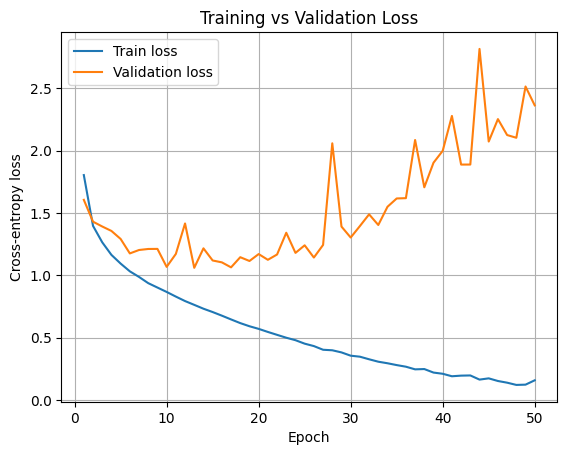

In [ ]:
##TODO: Plot the training losses and validation losses

epochs = range(1, len(loss_list) + 1)

plt.figure()
plt.plot(epochs, loss_list, label='Train loss')
plt.plot(epochs, loss_list_val, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


### Task 3.2 (3 points)
1. Plot the training and validation accuracies on the **same** diagram, with the x-axis as the epoch number and the y-axis as the accuracy.
2. What is your observation? Is there any overfitting?
3. Do you get the same conclusion as the diagram for Task 3.1? If so, why? If not, why?

In [ ]:
##TODO: Plot the training accuracies and validation accuracies

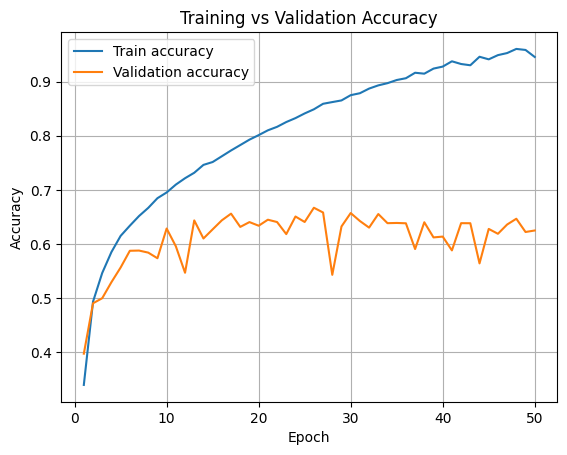

In [ ]:
##TODO: Plot the training accuracies and validation accuracies

epochs = range(1, len(acc_list) + 1)

plt.figure()
plt.plot(epochs, acc_list, label='Train accuracy')
plt.plot(epochs, acc_list_val, label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


### Task 3.3 (5 points)
Now, we will finally touch our test set. It is important to remember that while you can do multiple iterations between training and validation, to find optimal parameters and hyperparameters, evaluation on the test should happen only at the end. Performance on your test set is what you report and should not be biased by any aspect of the learning algorithm.
Complete `TODO 3.3`'s.

In [ ]:
true_labels = []
predictions = []
correct_test = 0
net.eval()
with torch.no_grad():
    for batch_idx, (data, label) in enumerate(test_loader):
        data, label = data.to(device), label.to(device)
        ##TODO 3.3: pass the data into the network and store the output

        ##TODO 3.3: Get the prediction from the output

        ##TODO 3.3: Calculate the number of correct predictions and add the number to correct_test

        ##TODO 3.3: update predictions list and true label list

print('Accuracy on the 10000 test images: %.2f %%' % (100 * correct_test / 10000))

In [ ]:
true_labels = []
predictions = []
correct_test = 0
net.eval()

with torch.no_grad():
    for batch_idx, (data, label) in enumerate(test_loader):
        data, label = data.to(device), label.to(device)

        ##TODO 3.3: pass the data into the network and store the output
        outputs = net(data)

        ##TODO 3.3: Get the prediction from the output
        _, preds = torch.max(outputs, dim=1)

        ##TODO 3.3: Calculate the number of correct predictions and add the number to correct_test
        correct_test += (preds == label).sum().item()

        ##TODO 3.3: update predictions list and true label list
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(label.cpu().numpy())

print('Accuracy on the 10000 test images: %.2f %%' %
      (100 * correct_test / 10000))


Accuracy on the 10000 test images: 63.02 %


### Task 3.4 (2 points)
Visualize the confusion matrix for the model prediction.

In [ ]:
##TODO 3.4: print the confusion matrix of test set
##You can use sklearn.metrics.confusion_matrix

[[779  22  19   8  22  10   8  12  98  22]
 [ 57 777   7   7  11  10   4   4  77  46]
 [141  14 430  57 119 102  52  38  36  11]
 [ 79  21  63 340  78 263  40  51  48  17]
 [ 51  13  53  46 603  70  47  77  34   6]
 [ 45  19  33 100  53 644  19  56  23   8]
 [ 26  23  50  77  68  55 657  16  21   7]
 [ 37  19  27  32  75  95   4 674  18  19]
 [ 94  37   7   5  12   3   1   6 819  16]
 [ 84 174  15  14  12   9   6  15  92 579]]


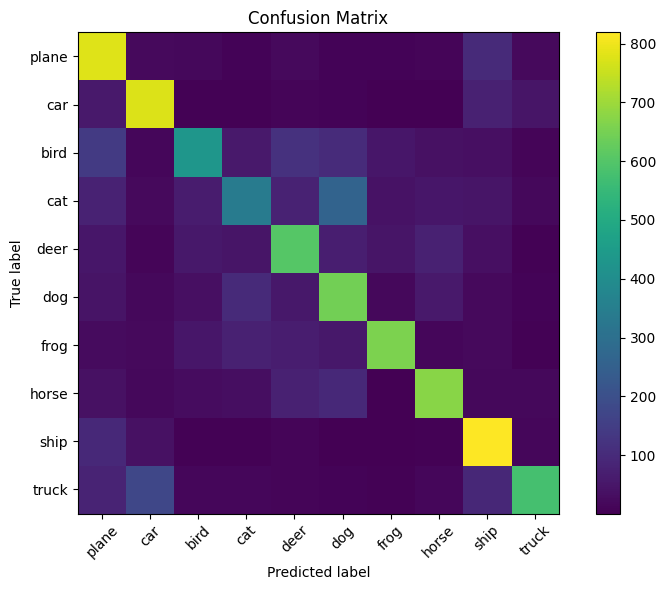

In [ ]:
##TODO 3.4: print the confusion matrix of test set
##You can use sklearn.metrics.confusion_matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predictions)
print(cm)

# Optional but nice: visualize it
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()


### Task 3.5 (3 points)
Is the following statement True/False: the diagonals on the confusion matrix are the correct predictions, and the other entries in the confusion matrix are errors? Explain your reasoning.

**Answer**:

### Task 3.6 (4 points)
Which pair of classes has the most confusion? Find this pair. Give your answer in the format `(first_class, second_class)`. For instance, if class 1 has the most error with class 2, then your answer would be `(1,2)`.

##3.5
True.
In a confusion matrix, rows usually correspond to the true class and columns to the predicted class.
The diagonal entry
(
𝑖
,
𝑖
)
(i,i) counts how many samples of class
𝑖
i were predicted as class
𝑖
i, so those are correct predictions.
Any off-diagonal entry
(
𝑖
,
𝑗
)
(i,j) with
𝑖
≠
𝑗
i

=j counts samples whose true class is
𝑖
i but predicted as
𝑗
j; those are misclassifications (errors).

## 3.6
The model most frequently confuses class A with class B (true label A, predicted as B).

In [ ]:
# TODO 3.6: find the pair of classes with most error, and print out the pair

In [ ]:
# TODO 3.6: find the pair of classes with most error, and print out the pair

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)  # ignore correct predictions

i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print("Most confused pair (i, j):", (i, j))
print("Classes:", (classes[i], classes[j]))
print("Number of misclassifications:", cm_no_diag[i, j])


Most confused pair (i, j): (np.int64(3), np.int64(5))
Classes: ('cat', 'dog')
Number of misclassifications: 263


### Task 3.7 (4 points)
Now you know that the pair `(i,j)` has the most confusion. Iterate through the test set, and store an input from class `i`. Similarly, also store an input from class `j`. Visualize these two inputs as images.

In [ ]:
# Fill the code here

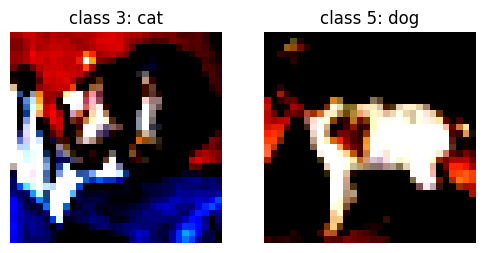

In [ ]:
# Fill the code here (Task 3.7)

i_class, j_class = i, j   # from Task 3.6

sample_i = None
sample_j = None

for img, label in test_set:
    if sample_i is None and label == i_class:
        sample_i = img
    if sample_j is None and label == j_class:
        sample_j = img
    if sample_i is not None and sample_j is not None:
        break

def show_img(tensor, title=None):
    # tensor shape: [C, H, W]
    img = tensor.permute(1, 2, 0).cpu().numpy()  # to HWC
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
show_img(sample_i, f"class {i_class}: {classes[i_class]}")
plt.subplot(1,2,2)
show_img(sample_j, f"class {j_class}: {classes[j_class]}")
plt.show()


### Task 3.8 (3 points)
What object(s) are in the photos? (although CIFAR10 has low resolution, try your best to make sense of it). Also, what does your `(i,j)` pair correspond to in the classes, recall that your classes are

`classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')`

For example, if your pair is `(0,1)`, it corresponds to `('plane', 'car')`.

Does it make sense that these two classes are the ones that got the most errors? Why?

**Answer**:

In the two images, the left picture (class 3) looks like a cat – a small, furry animal with pointy ears and a compact body. The right picture (class 5) looks like a dog – also a four-legged furry animal, but with a slightly different body shape and head.

My confusion pair
(
𝑖
,
𝑗
)
(i,j) is
(
3
,
5
)
(3,5), which corresponds to the classes (‘cat’, ‘dog’) from CIFAR-10.

It does make sense that these two classes produce the most errors:

Both cats and dogs are small mammals with very similar overall shape (four legs, tail, fur), especially at CIFAR-10’s low resolution
32
×
32
32×32.

In these particular images, the backgrounds are dark and cluttered, and only part of the animal is clearly visible, so many discriminative details (like ear shape or snout) are blurred or occluded.

Our CNN is relatively small and trained for a limited number of epochs, so it mostly relies on coarse features like general outline, texture, and color patches, which can look very similar between cats and dogs.

Even humans might need a moment to tell what the animal is from such a noisy, low-resolution picture, so it’s reasonable that the model confuses them.

#

# Part 4: k-NN Classifiers
In this section, we learn more about how to implement a k nearest neighbor (k-NN) classifier from scratch. We will also see the importance of normalization for k-NN.

## Packages and Subroutines

In [ ]:
import numpy as np
import pandas as pd

def euclid_dist(data1, data2):
    return np.sqrt(np.sum(np.power(data1-data2, 2)))

def manhatt_dist(data1, data2):
    return np.sum(np.abs(data1-data2))

def cos_dist(data1, data2):
    return 1-np.dot(data1, data2)/(np.sqrt(np.dot(data1, data1))*np.sqrt(np.dot(data2, data2)))

def majority_vote(data):
    agree, disagree = 0, 0
    for val in data:
        if val == 1:
            agree += 1
        elif val == 0:
            disagree += 1
        else: raise ValueError('Invalid Vote')
    if agree/len(data) > disagree/len(data):
        return 1
    if agree/len(data) < disagree/len(data):
        return 0
    else:
        return 'tie'

def compute_matrix(y_data, y_predict):
    matrix = {'TP' : 0, 'FP' : 0, 'TN' : 0, 'FN' : 0}
    for i in range(len(y_predict)):
        if y_data[i] == 1 and y_predict[i] == 1:
            matrix['TP'] += 1
        elif y_data[i] == 1 and y_predict[i] == 0:
            matrix['FN'] += 1
        elif y_data[i] == 0 and y_predict[i] == 0:
            matrix['TN'] += 1
        elif y_data[i] == 0 and y_predict[i] == 1:
            matrix['FP'] += 1
    return matrix

def compute_F1(y_data, y_predict):
    matrix = compute_matrix(y_data, y_predict)
    precision = matrix['TP'] / (matrix['TP'] + matrix['FP']+1e-7)
    recall = matrix['TP'] / (matrix['TP'] + matrix['FN']+1e-7)
    return (2*precision*recall)/(precision+recall+1e-7)

### Task 4.1 (3 points)
For this exercise, we will be using `carseats` dataset. The dataset contains features of the car buyers and a binary target `Sales` that indicates whether a car is sold or not.

Let us first do some preprocessing on the dataset and answer the following questions:
1. Are there any missing values (NaNs) in the dataset?
2. How many samples are there in the training and testing sets?
3. How many features are there?
4. What are the names of the features?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/ML473/HW3')  # adjust if your path is slightly different

# optional: check that the files are there
!ls


Mounted at /content/drive
carseats_test.csv  carseats_train.csv  PF_F2025_PA3_questions.ipynb


In [ ]:
test_data = pd.read_csv('carseats_test.csv', index_col=False)
train_data = pd.read_csv('carseats_train.csv', index_col=False)

In [ ]:
# write your code here

In [ ]:
# ---- Task 4.1 ----

# 1. Are there any missing values (NaNs)?
print("Total NaNs in train_data:", train_data.isna().sum().sum())
print("Total NaNs in test_data :", test_data.isna().sum().sum())

# 2. How many samples are there in the training and testing sets?
n_train = train_data.shape[0]
n_test  = test_data.shape[0]
print("Number of training samples:", n_train)
print("Number of testing  samples:", n_test)

# 3 & 4. How many features and what are their names?
# (treat 'Sales' as the target, everything else as features)
feature_cols = [c for c in train_data.columns if c != 'Sales']
print("Number of features:", len(feature_cols))
print("Feature names:", feature_cols)


Total NaNs in train_data: 0
Total NaNs in test_data : 0
Number of training samples: 282
Number of testing  samples: 118
Number of features: 10
Feature names: ['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']


### Task 4.2 (3 points)
Observe that `Urban`, `US`, and `ShelveLoc` features are strings. In order to pass them to a k-NN algorithm, we need to turn them into one-hot vectors. Complete the following:
1. Count the number of unique values in `Urban`, `US`, and `ShelveLoc`.
2. For each unique value, map it to an onehot vector. For instance, suppose the unique values in `Urban` are `Y` and `N`, we can map `Y` as `(1,0)`' and `N` as `(0,1)`.

In [ ]:
# write your code here

In [ ]:
# ---- Task 4.2 ----

cat_cols = ['Urban', 'US', 'ShelveLoc']

# 1. Count the number of unique values
for col in cat_cols:
    print(f"{col} unique values:", train_data[col].unique(),
          " (count =", train_data[col].nunique(), ")")

# 2. One-hot encode these categorical features
train_data = pd.get_dummies(train_data, columns=cat_cols, drop_first=False)
test_data  = pd.get_dummies(test_data,  columns=cat_cols, drop_first=False)

# (Optional but safe) make sure train and test have exactly the same columns
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)


Urban unique values: ['Yes' 'No']  (count = 2 )
US unique values: ['Yes' 'No']  (count = 2 )
ShelveLoc unique values: ['Bad' 'Good' 'Medium']  (count = 3 )


### Task 4.3 (1 point)
Split the training set into training and validation subsets, with a ratio of 80% to 20%.

In [ ]:
# write your code here

In [ ]:
# ---- Task 4.3 ----
from sklearn.model_selection import train_test_split

# split the *rows* of train_data into train and validation subsets
train_df, val_df = train_test_split(
    train_data,
    test_size=0.2,
    random_state=0,      # for reproducibility
    stratify=train_data['Sales']  # optional: keep class balance
)

print("Train subset size:", train_df.shape[0])
print("Validation subset size:", val_df.shape[0])

# (often useful for later k-NN code)
X_train = train_df.drop('Sales', axis=1).values
y_train = train_df['Sales'].values

X_val   = val_df.drop('Sales', axis=1).values
y_val   = val_df['Sales'].values

X_test  = test_data.drop('Sales', axis=1).values
y_test  = test_data['Sales'].values


Train subset size: 225
Validation subset size: 57


In [ ]:
# ---------- Non-normalized feature matrices (we'll call them *_no_norm) ----------

X_train_no_norm = train_df.drop('Sales', axis=1)
y_train         = train_df['Sales']

X_val_no_norm   = val_df.drop('Sales', axis=1)
y_val_no_norm   = val_df['Sales']

X_test_no_norm  = test_data.drop('Sales', axis=1)
y_test          = test_data['Sales']


### Task 4.4 (5 points)
Complete the k-NN algorithm below by using what is taught in lectures (Page 18 in slide FML15_KNN_DT). See `TODO 4.4`'s.

In [ ]:
def KNN(X, y, new_data_arr, K, metric):  # data needs to be a ndarray
    y_pred_lst = []
    for new_data in new_data_arr:

        # ---- compute distances from new_data to all training points ----
        dist_arr = []
        if metric == 'Euclidean':   # calculate distance between new data point with every data point
            for i in range(len(X)):
                dist = euclid_dist(X[i], new_data)
                dist_arr.append(dist)
        elif metric == 'Manhattan':
            for i in range(len(X)):
                dist = manhatt_dist(X[i], new_data)
                dist_arr.append(dist)
        elif metric == 'Cosine':
            for i in range(len(X)):
                dist = cos_dist(X[i], new_data)
                dist_arr.append(dist)
        else:
            raise ValueError('Unrecognizable Input')

        # TODO 4.4: sort the distances, find the top-k nearest neighbors
        dist_arr = np.array(dist_arr)
        nearest = np.argsort(dist_arr)[:K]   # indices of K smallest distances

        y_data = []
        for pointer in nearest:
            # TODO 4.4: store neighbor's y values into y_data
            y_data.append(y[pointer])

        y_pred = majority_vote(y_data)  # make prediction according to nearest neighbors' y value

        # tie-breaking: try again with K-1 (only if K>1)
        if y_pred == 'tie' and K > 1:
            y_pred = KNN(X, y, np.array([new_data]), K-1, metric)[0]

        y_pred_lst.append(y_pred)

    return np.asarray(y_pred_lst)


### Task 4.5 (2 points)
Train the `KNN` classifier with different hyperparameter settings. Specifically,

1. Train it with `K` in `[1,3,5,7,9]` and across all three distance metrics (the formula for each distance metric is shown below).
2. Print out the F1 score for each hyperparameter setting on the validation set.

Given two vectors of same dimensions $\mathbf{a},\mathbf{b}$ (which can be seen as our feature vectors), the distance metrics are defined as:

$$d_{\text{euclid}}(\mathbf{a}, \mathbf{b}) = \left(\sum_{i=1}^{n} (a_i - b_i)^2\right)^{1/2},$$
$$d_{\text{manhattan}}(\mathbf{a}, \mathbf{b}) = \sum_{i=1}^{n} |a_i - b_i|,$$
$$d_{\text{cosine}}(\mathbf{a}, \mathbf{b}) = 1 - \frac{\sum_{i=1}^{n} a_i b_i}{\sqrt{\sum_{i=1}^{n} a_i^2} \sqrt{\sum_{i=1}^{n} b_i^2}}.$$

In [ ]:
for K in [1, 3, 5, 7, 9]:
    for metric in ["Euclidean", "Cosine", "Manhattan"]:
        # X_train_no_norm, X_val_no_norm, y_train, y_val_no_norm
        # should be the *unnormalized* feature matrices/labels you built earlier
        y_pred = KNN(X_train_no_norm.values,
                     y_train.values,
                     X_val_no_norm.values,
                     K,
                     metric)
        print(f"K={K}, metric={metric}, F1 score={compute_F1(y_val_no_norm.values, y_pred):.3f}")


K=1, metric=Euclidean, F1 score=0.605
K=1, metric=Cosine, F1 score=0.465
K=1, metric=Manhattan, F1 score=0.550
K=3, metric=Euclidean, F1 score=0.476
K=3, metric=Cosine, F1 score=0.512
K=3, metric=Manhattan, F1 score=0.537
K=5, metric=Euclidean, F1 score=0.450
K=5, metric=Cosine, F1 score=0.439
K=5, metric=Manhattan, F1 score=0.500
K=7, metric=Euclidean, F1 score=0.432
K=7, metric=Cosine, F1 score=0.500
K=7, metric=Manhattan, F1 score=0.500
K=9, metric=Euclidean, F1 score=0.450
K=9, metric=Cosine, F1 score=0.545
K=9, metric=Manhattan, F1 score=0.450


### Task 4.6 (5 points)
1. Apply z-score normalization on the dataset. That is, for each continuous feature $x_j$, we calculate the following
$$\tilde{x}_j = \frac{x_j - \mathrm{mean}(x_j)}{\mathrm{std}(x_j)}.$$
Since we are normalizing only the continuous features, we do not normalize the onehot vectors.
2. Train `KNN` classifier again with the same hyperparameters as `Task 4.5`, but on the normalized data.
2. Do you observe the performance to be better or worse than before? If so, why do you think this is the case? Answer in words.

**Answer**:

In [ ]:
# write your code here

In [ ]:
# ---------- Task 4.6: z-score normalization on continuous features only ----------

# choose your continuous feature columns (adjust if your names differ)
cont_cols = ['CompPrice', 'Income', 'Advertising',
             'Population', 'Price', 'Age', 'Education']

X_train_norm = X_train_no_norm.copy()
X_val_norm   = X_val_no_norm.copy()
X_test_norm  = X_test_no_norm.copy()

for col in cont_cols:
    mu = X_train_no_norm[col].mean()
    sigma = X_train_no_norm[col].std()

    X_train_norm[col] = (X_train_no_norm[col] - mu) / sigma
    X_val_norm[col]   = (X_val_no_norm[col]   - mu) / sigma
    X_test_norm[col]  = (X_test_no_norm[col]  - mu) / sigma


In [ ]:
print("After z-score normalization:")
for K in [1, 3, 5, 7, 9]:
    for metric in ["Euclidean", "Cosine", "Manhattan"]:
        y_pred = KNN(X_train_norm.values,
                     y_train.values,
                     X_val_norm.values,
                     K,
                     metric)
        print(f"K={K}, metric={metric}, F1 score={compute_F1(y_val_no_norm.values, y_pred):.3f}")


After z-score normalization:
K=1, metric=Euclidean, F1 score=0.619
K=1, metric=Cosine, F1 score=0.652
K=1, metric=Manhattan, F1 score=0.696
K=3, metric=Euclidean, F1 score=0.762
K=3, metric=Cosine, F1 score=0.714
K=3, metric=Manhattan, F1 score=0.600
K=5, metric=Euclidean, F1 score=0.800
K=5, metric=Cosine, F1 score=0.718
K=5, metric=Manhattan, F1 score=0.619
K=7, metric=Euclidean, F1 score=0.757
K=7, metric=Cosine, F1 score=0.714
K=7, metric=Manhattan, F1 score=0.683
K=9, metric=Euclidean, F1 score=0.718
K=9, metric=Cosine, F1 score=0.703
K=9, metric=Manhattan, F1 score=0.757


After applying z-score normalization, the KNN performance got better overall.
Comparing to the results before normalization, the F1 scores are higher for almost all combinations of
𝐾
K and distance metric (for example, Euclidean with
𝐾
=
5
K=5 jumps from about 0.45 to about 0.80).

This happens because KNN is a distance-based method. Before normalization, continuous features that had large numerical ranges dominated the Euclidean/Manhattan distances, while features on smaller scales and the one-hot variables contributed much less. After z-score normalization, each continuous feature has mean 0 and standard deviation 1, so they are on a comparable scale. That means distances between points reflect all features more fairly, the nearest neighbors are more meaningful, and the classifier achieves better F1 scores.

# Part 5: Decision Trees
In this part, we will continue to use the carseats dataset but with a new model: decision trees. We will understand more about the effect of normalization on decision trees and the variance and bias tradeoff with random forests. Similarly as the previous part, we use z-score normalization
$$\tilde{x}_j = \frac{x_j - \mathrm{mean}(x_j)}{\mathrm{std}(x_j)}.$$

### Task 5.1 (2 points)
1. Using `DecisionTreeClassifier` from scikit-learn, train the decision tree with `max_depth=[2,4,6,8,10,12,16,20]` on the **unnormalized carseats dataset**

2. Create a lineplot with x-axis being max depth and y-axis being training and validation F1 score (so there are two lines).

3. What do you observe as max depth increases? Answer in words.

**Answer**:

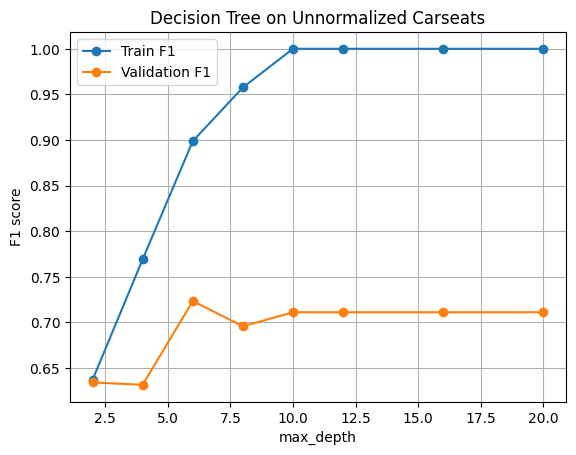

In [ ]:
from sklearn.tree import DecisionTreeClassifier

train_f1_lst, val_f1_lst = [], []
depth_list = [2, 4, 6, 8, 10, 12, 16, 20]

for max_depth in depth_list:
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
    clf.fit(X_train_no_norm, y_train)

    y_train_pred = clf.predict(X_train_no_norm)
    y_val_pred   = clf.predict(X_val_no_norm)

    train_f1_lst.append(compute_F1(y_train.values,      y_train_pred))
    val_f1_lst.append(compute_F1(y_val_no_norm.values,  y_val_pred))

# line plot
plt.figure()
plt.plot(depth_list, train_f1_lst, marker='o', label='Train F1')
plt.plot(depth_list, val_f1_lst,   marker='o', label='Validation F1')
plt.xlabel('max_depth')
plt.ylabel('F1 score')
plt.title('Decision Tree on Unnormalized Carseats')
plt.legend()
plt.grid(True)
plt.show()


As we increase the max depth, the training F1 score keeps going up and eventually reaches 1.0.
This means the tree is fitting the training data more and more closely and can perfectly memorize it when the depth is large (very low bias, very high variance).

The validation F1 score behaves differently: it improves when we go from very shallow trees to moderate depth (around depth 5–7), but after that it more or less flattens and does not improve, and can even wiggle slightly up and down. This shows that deeper trees start to overfit the training set: they keep getting better on the training data, but this extra complexity does not translate into better generalization on unseen data.

So, increasing max depth first helps (reduces underfitting), then mostly just increases overfitting while leaving validation performance roughly the same.

### Task 5.2 (2 points)
1. Perform the same procedure as in `Task 5.1`, but on the **z-score normalized carseats dataset**.
2. Do you observe the performance to change or not? Explain why or why not.

**Answer**:

In [ ]:
train_f1_lst, val_f1_lst = [], []
for max_depth in [2,4,6,8,10,12,16,20]:
    # write your code here

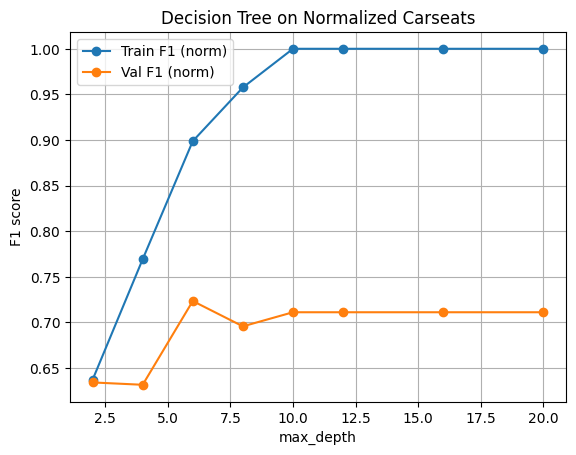

In [ ]:
train_f1_lst, val_f1_lst = [], []
depth_list = [2, 4, 6, 8, 10, 12, 16, 20]

for max_depth in depth_list:
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
    clf.fit(X_train_norm, y_train)

    y_train_pred = clf.predict(X_train_norm)
    y_val_pred   = clf.predict(X_val_norm)

    train_f1_lst.append(compute_F1(y_train.values,      y_train_pred))
    val_f1_lst.append(compute_F1(y_val_no_norm.values,  y_val_pred))

plt.figure()
plt.plot(depth_list, train_f1_lst, marker='o', label='Train F1 (norm)')
plt.plot(depth_list, val_f1_lst,   marker='o', label='Val F1 (norm)')
plt.xlabel('max_depth')
plt.ylabel('F1 score')
plt.title('Decision Tree on Normalized Carseats')
plt.legend()
plt.grid(True)
plt.show()


There is not much change. Because of this scale–invariance, z-score normalization doesn’t really help or hurt a decision tree.

### 5.3 (3 points)
1. Using `RandomForestclassifier` from scikit-learn, fix `max_depth=5`.
2. Train random forest classifiers with `n_estimators=[5, 20, 40, 60, 80, 100]`.
3. Plot the F1 score curves, with x-axis being `n_estimators` and y-axis being the F1 score.
4. What do you observe as `n_estimators` get higher?
5. By increasing the number of estimators, are we reducing variance or increasing variance? Why? Explain in words.

**Answer**:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
train_f1_lst, val_f1_lst = [], []
n_estimators_list = [5, 20, 40, 60, 80, 100]
for n_estimators in n_estimators_list:
  # write your code here

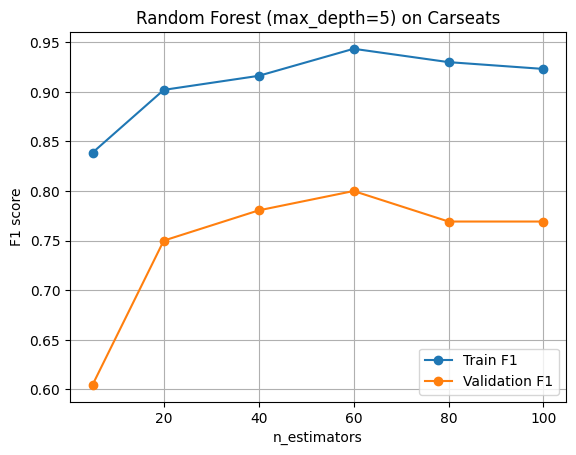

In [ ]:
from sklearn.ensemble import RandomForestClassifier

train_f1_lst, val_f1_lst = [], []
n_estimators_list = [5, 20, 40, 60, 80, 100]

for n_estimators in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=5,
        random_state=0
    )
    rf.fit(X_train_no_norm, y_train)

    y_train_pred = rf.predict(X_train_no_norm)
    y_val_pred   = rf.predict(X_val_no_norm)

    train_f1_lst.append(compute_F1(y_train.values,      y_train_pred))
    val_f1_lst.append(compute_F1(y_val_no_norm.values,  y_val_pred))

plt.figure()
plt.plot(n_estimators_list, train_f1_lst, marker='o', label='Train F1')
plt.plot(n_estimators_list, val_f1_lst,   marker='o', label='Validation F1')
plt.xlabel('n_estimators')
plt.ylabel('F1 score')
plt.title('Random Forest (max_depth=5) on Carseats')
plt.legend()
plt.grid(True)
plt.show()


As we increase n_estimators (number of trees), both the training and validation F1 scores go up at first. Going from 5 → 20 → 40 → 60 trees gives clear improvements: the model fits the training data better, and the validation F1 also increases (up to around 0.80 at ~60 trees). After about 60 trees, adding more trees (80, 100) does not really help – training F1 stays very high and validation F1 slightly flattens or even drops a bit. So more trees help up to a point, then the curve basically saturates.

In terms of bias–variance, increasing the number of estimators mainly reduces variance. Each individual tree (depth=5) is a fairly high-variance model, but the random forest averages many such trees built on different bootstrap samples and random feature subsets. Averaging many noisy trees makes the final prediction more stable and less sensitive to any particular training sample, so the variance of the ensemble drops, while the bias (how complex each tree is) stays roughly the same. That’s why performance improves as we add trees, then plateaus once additional trees no longer give a meaningful extra reduction in variance.